# Loading the tarot json dataset

In [2]:
import json
import random

# 1. SAMPLE TAROT DATASET (Simulated JSON structure)
# Replace this string with your actual file path if loading an external JSON file
tarot_json_data = """
{
  "cards": [
    {
      "name": "The Fool",
      "number": "0",
      "arcana": "Major Arcana",
      "suit": "Trump",
      "meanings": {
        "upright": ["New beginnings", "Spontaneity", "Faith"],
        "reversed": ["Holding back", "Recklessness", "Risk-taking"]
      },
      "description": "A young man stands at the edge of a cliff, looking into the future."
    },
    {
      "name": "The Magician",
      "number": "1",
      "arcana": "Major Arcana",
      "suit": "Trump",
      "meanings": {
        "upright": ["Willpower", "Desire", "Creation", "Manifestation"],
        "reversed": ["Illusion", "Out of touch", "Wasted talent"]
      },
      "description": "A figure stands with one hand pointing to the sky, the other to the earth."
    },
    {
      "name": "Ace of Cups",
      "number": "1",
      "arcana": "Minor Arcana",
      "suit": "Cups",
      "meanings": {
        "upright": ["New feelings", "Spirituality", "Intuition"],
        "reversed": ["Emotional loss", "Blocked creativity", "Empty heart"]
      },
      "description": "A cup overflows with five streams of water."
    }
  ]
}
"""

class TarotEngine:
    def __init__(self, data_source, is_file=False):
        """Initializes the engine by loading JSON data."""
        if is_file:
            with open(data_source, 'r', encoding='utf-8') as f:
                self.data = json.load(f)
        else:
            self.data = json.loads(data_source)

        self.cards = self.data.get("cards", [])

    def draw_cards(self, num_cards=1):
        """Draws a specified number of unique cards with random orientations."""
        if num_cards > len(self.cards):
            raise ValueError("Requested more cards than available in the dataset.")

        # Select unique cards to prevent drawing duplicates in a single reading
        selected_cards = random.sample(self.cards, num_cards)
        reading = []

        for card in selected_cards:
            # 50% chance for Upright, 50% chance for Reversed orientation
            orientation = random.choice(["Upright", "Reversed"])
            meanings = card["meanings"]["upright"] if orientation == "Upright" else card["meanings"]["reversed"]

            reading.append({
                "name": card["name"],
                "arcana": card["arcana"],
                "suit": card["suit"],
                "orientation": orientation,
                "key_meanings": meanings,
                "description": card.get("description", "No description available.")
            })
        return reading

    def Multi_card_spread(self, spread_name="Three Cards"):
        """Predefined spreads mapping drawn cards to specific positions."""
        spread_layouts = {
            "One Card": ["Daily Guidance"],
            "Three Cards": ["Past", "Present", "Future"],
            "Decision": ["Option A", "Option B", "Final Outcome"]
        }

        positions = spread_layouts.get(spread_name, ["Past", "Present", "Future"])
        drawn = self.draw_cards(len(positions))

        print(f"--- {spread_name.upper()} SPREAD READING --- \n")
        for pos, card in zip(positions, drawn):
            print(f"🔮 POSITION: {pos}")
            print(f"🃏 CARD: {card['name']} ({card['orientation']})")
            print(f"✨ Type: {card['arcana']} | Suit: {card['suit']}")
            print(f"💡 Key Meanings: {', '.join(card['key_meanings'])}")
            print(f"📖 Description: {card['description']}")
            print("-" * 40)

In [3]:
engine = TarotEngine(tarot_json_data, is_file=False)

#Displyed a random card

In [4]:
engine.Multi_card_spread("Three Cards")

--- THREE CARDS SPREAD READING --- 

🔮 POSITION: Past
🃏 CARD: The Magician (Upright)
✨ Type: Major Arcana | Suit: Trump
💡 Key Meanings: Willpower, Desire, Creation, Manifestation
📖 Description: A figure stands with one hand pointing to the sky, the other to the earth.
----------------------------------------
🔮 POSITION: Present
🃏 CARD: Ace of Cups (Upright)
✨ Type: Minor Arcana | Suit: Cups
💡 Key Meanings: New feelings, Spirituality, Intuition
📖 Description: A cup overflows with five streams of water.
----------------------------------------
🔮 POSITION: Future
🃏 CARD: The Fool (Upright)
✨ Type: Major Arcana | Suit: Trump
💡 Key Meanings: New beginnings, Spontaneity, Faith
📖 Description: A young man stands at the edge of a cliff, looking into the future.
----------------------------------------


#Model to draw card

In [28]:
import json
import random
import os
import base64
import ipywidgets as widgets
from IPython.display import display, HTML

# 1. Automatically unzip 'cards.zip' if it exists in Colab
if os.path.exists("cards.zip") and not os.path.exists("cards"):
    print("📦 Extracting your card images...")
    !unzip -q cards.zip -d /content/
    print("✅ Extraction complete!")

# 2. File Paths
JSON_PATH = "tarot-images.json"
IMAGE_FOLDER = "cards"

# 3. Load Dataset
try:
    with open(JSON_PATH, 'r', encoding='utf-8') as f:
        data = json.load(f)
        tarot_dataset = data.get('cards', data) if isinstance(data, dict) else data
    print(f"✅ Loaded {len(tarot_dataset)} cards successfully from '{JSON_PATH}'!")
except Exception as e:
    print(f"❌ Error loading JSON: {e}")
    tarot_dataset = []

# 4. Base64 Image Converter for your local files
def get_image_base64(img_name):
    img_path = os.path.join(IMAGE_FOLDER, img_name)
    if os.path.exists(img_path):
        with open(img_path, "rb") as image_file:
            encoded_string = base64.b64encode(image_file.read()).decode('utf-8')
            return f"data:image/jpeg;base64,{encoded_string}"
    return "https://via.placeholder.com/180x300?text=Image+Not+Found"

# 5. Render Card HTML
def render_card_html(card, position_title=""):
    img_src = get_image_base64(card.get('img', ''))

    keywords = "".join([f'<span style="background:#2a2440; color:#d4af37; padding:2px 8px; border-radius:10px; font-size:11px; margin:2px; display:inline-block;">{kw}</span>' for kw in card.get('keywords', [])])
    fortune = "".join([f"<li>{item}</li>" for item in card.get('fortune_telling', [])])
    light_meanings = "".join([f"<li>{item}</li>" for item in card.get('meanings', {}).get('light', [])])
    shadow_meanings = "".join([f"<li>{item}</li>" for item in card.get('meanings', {}).get('shadow', [])])

    return f"""
    <div style="background-color: #1c182e; color: #f0e6d2; border: 1px solid #d4af37; border-radius: 12px; padding: 15px; width: 280px; font-family: sans-serif; box-sizing: border-box; display: flex; flex-direction: column; align-items: center;">
        <h4 style="color: #d4af37; margin: 0 0 10px 0; text-transform: uppercase;">{position_title}</h4>

        <div style="width: 180px; height: 300px; border-radius: 8px; overflow: hidden; border: 2px solid #d4af37; margin-bottom: 10px;">
            <img src="{img_src}" style="width: 100%; height: 100%; object-fit: cover;" />
        </div>

        <h3 style="margin: 5px 0 2px 0; text-align: center;">{card.get('name', 'Unknown Card')}</h3>
        <p style="color: #a095b5; font-size: 12px; margin: 0 0 10px 0;">{card.get('arcana', '')} • Suit: {card.get('suit', '')}</p>

        <div style="text-align: center; margin-bottom: 10px;">{keywords}</div>

        <div style="font-size: 12px; line-height: 1.4; width: 100%; text-align: left;">
            <p style="margin: 4px 0;"><strong>Archetype:</strong> {card.get('Archetype', 'N/A')}</p>

            <h5 style="color: #d4af37; margin: 8px 0 2px 0;">🔮 Fortune Telling</h5>
            <ul style="padding-left: 16px; margin: 0;">{fortune}</ul>

            <h5 style="color: #8eda85; margin: 8px 0 2px 0;">☀️ Light Meanings</h5>
            <ul style="padding-left: 16px; margin: 0;">{light_meanings}</ul>

            <h5 style="color: #e87a7a; margin: 8px 0 2px 0;">🌙 Shadow Meanings</h5>
            <ul style="padding-left: 16px; margin: 0;">{shadow_meanings}</ul>
        </div>
    </div>
    """

def draw_cards(count):
    if not tarot_dataset:
        print("Dataset not loaded properly.")
        return

    output_area.clear_output()
    cards = random.sample(tarot_dataset, count)
    positions = ["Past / Cause", "Present / Situation", "Future / Outcome"] if count == 3 else ["Daily Guidance"]

    cards_html = [render_card_html(card, positions[i]) for i, card in enumerate(cards)]

    flex_container = f"""
    <div style="display: flex; flex-wrap: wrap; gap: 20px; justify-content: center; background-color: #0f0c1b; padding: 20px; border-radius: 12px; margin-top: 15px;">
        {''.join(cards_html)}
    </div>
    """
    with output_area:
        display(HTML(flex_container))

# 6. UI Controls
btn_1card = widgets.Button(description="Draw 1 Card", button_style='warning')
btn_3card = widgets.Button(description="Draw 3-Card Spread", button_style='warning')
output_area = widgets.Output()

btn_1card.on_click(lambda b: draw_cards(1))
btn_3card.on_click(lambda b: draw_cards(3))

display(widgets.HBox([btn_1card, btn_3card]))
display(output_area)

✅ Loaded 78 cards successfully from 'tarot-images.json'!


Output()

# Manually drawn card by code


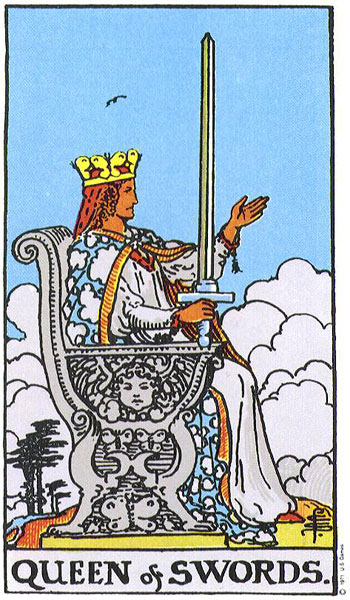

In [ ]:
# Run this in a new cell for a quick 1-card draw in its own cell output
from IPython.display import display, HTML
import random

single_card = random.choice(tarot_dataset)
display(HTML(render_card_html(single_card, "Daily Guidance")))

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Verify dataset is available in global scope before setting up buttons
if 'tarot_dataset' in globals() and tarot_dataset:
    btn_1card = widgets.Button(description="Draw 1 Card", button_style='warning')
    btn_3card = widgets.Button(description="Draw 3-Card Spread", button_style='warning')
    output_area = widgets.Output()

    btn_1card.on_click(lambda b: draw_cards(1))
    btn_3card.on_click(lambda b: draw_cards(3))

    display(widgets.HBox([btn_1card, btn_3card]))
    display(output_area)
else:
    print("⚠️ Please run your dataset setup cell first so 'tarot_dataset' is loaded!")

Output()

# Integrating LLM

In [ ]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.6/258.6 kB 16.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.56.2 which is incompatible.


In [ ]:
import json
import random
import os
import base64
import ipywidgets as widgets
from IPython.display import display, HTML
from google import genai
from google.colab import userdata

# -------------------------------------------------------------
# 1. SETUP GEMINI CLIENT & FILE PATHS
# -------------------------------------------------------------
# Initialize Gemini API using Colab secrets
try:
    api_key = userdata.get('GEMINI_API_KEY')
    ai_client = genai.Client(api_key=api_key)
    print("✅ Gemini API connected successfully!")
except Exception as e:
    ai_client = None
    print("⚠️ Gemini API Key not found in Secrets. AI interpretations will be disabled.")

JSON_PATH = "tarot-images.json"
IMAGE_FOLDER = "cards"

# Load Dataset
try:
    with open(JSON_PATH, 'r', encoding='utf-8') as f:
        data = json.load(f)
        tarot_dataset = data.get('cards', data) if isinstance(data, dict) else data
    print(f"✅ Loaded {len(tarot_dataset)} cards successfully!")
except Exception as e:
    print(f"❌ Error loading JSON: {e}")
    tarot_dataset = []

# -------------------------------------------------------------
# 2. HELPER FUNCTIONS
# -------------------------------------------------------------
def get_image_base64(img_name):
    """Converts local image file to base64 for reliable Colab HTML display."""
    img_path = os.path.join(IMAGE_FOLDER, img_name)
    if os.path.exists(img_path):
        with open(img_path, "rb") as image_file:
            encoded_string = base64.b64encode(image_file.read()).decode('utf-8')
            return f"data:image/jpeg;base64,{encoded_string}"
    return "https://via.placeholder.com/180x300?text=Image+Not+Found"

def render_card_html(card, position_title=""):
    img_src = get_image_base64(card.get('img', ''))
    keywords = "".join([f'<span style="background:#2a2440; color:#d4af37; padding:2px 8px; border-radius:10px; font-size:11px; margin:2px; display:inline-block;">{kw}</span>' for kw in card.get('keywords', [])])
    fortune = "".join([f"<li>{item}</li>" for item in card.get('fortune_telling', [])])
    light_meanings = "".join([f"<li>{item}</li>" for item in card.get('meanings', {}).get('light', [])])
    shadow_meanings = "".join([f"<li>{item}</li>" for item in card.get('meanings', {}).get('shadow', [])])

    return f"""
    <div style="background-color: #1c182e; color: #f0e6d2; border: 1px solid #d4af37; border-radius: 12px; padding: 15px; width: 280px; font-family: sans-serif; box-sizing: border-box; display: flex; flex-direction: column; align-items: center;">
        <h4 style="color: #d4af37; margin: 0 0 10px 0; text-transform: uppercase;">{position_title}</h4>

        <div style="width: 180px; height: 300px; border-radius: 8px; overflow: hidden; border: 2px solid #d4af37; margin-bottom: 10px;">
            <img src="{img_src}" style="width: 100%; height: 100%; object-fit: cover;" />
        </div>

        <h3 style="margin: 5px 0 2px 0; text-align: center;">{card.get('name', 'Unknown Card')}</h3>
        <p style="color: #a095b5; font-size: 12px; margin: 0 0 10px 0;">{card.get('arcana', '')} • Suit: {card.get('suit', '')}</p>

        <div style="text-align: center; margin-bottom: 10px;">{keywords}</div>

        <div style="font-size: 12px; line-height: 1.4; width: 100%; text-align: left;">
            <p style="margin: 4px 0;"><strong>Archetype:</strong> {card.get('Archetype', 'N/A')}</p>

            <h5 style="color: #d4af37; margin: 8px 0 2px 0;">🔮 Fortune Telling</h5>
            <ul style="padding-left: 16px; margin: 0;">{fortune}</ul>

            <h5 style="color: #8eda85; margin: 8px 0 2px 0;">☀️ Light Meanings</h5>
            <ul style="padding-left: 16px; margin: 0;">{light_meanings}</ul>

            <h5 style="color: #e87a7a; margin: 8px 0 2px 0;">🌙 Shadow Meanings</h5>
            <ul style="padding-left: 16px; margin: 0;">{shadow_meanings}</ul>
        </div>
    </div>
    """

def generate_ai_interpretation(drawn_cards, positions):
    """Sends the drawn card details to Gemini to generate a cohesive Tarot reading."""
    if not ai_client:
        return "<p style='color: #a095b5;'>Connect your Gemini API Key to enable AI interpretations.</p>"

    # Format card information into text for the LLM
    cards_context = ""
    for idx, card in enumerate(drawn_cards):
        cards_context += f"\nPosition: {positions[idx]}\n"
        cards_context += f"Card Name: {card.get('name')}\n"
        cards_context += f"Keywords: {', '.join(card.get('keywords', []))}\n"
        cards_context += f"Light Meanings: {', '.join(card.get('meanings', {}).get('light', []))}\n"
        cards_context += f"Shadow Meanings: {', '.join(card.get('meanings', {}).get('shadow', []))}\n"

    prompt = f"""
    You are an insightful, empathetic, and intuitive Tarot reader.
    Synthesize the following drawn card(s) into a cohesive, meaningful reading.
    Connect the card meanings together naturally rather than just listing them. Keep it grounded, supportive, and engaging.

    Cards Drawn:
    {cards_context}

    Format your output cleanly in 2-3 short paragraphs using HTML tags (<p>, <strong>, etc.) styled for a dark UI background.
    """

    try:
        response = ai_client.models.generate_content(
            model='gemini-2.5-flash',
            contents=prompt,
        )
        return response.text
    except Exception as e:
        return f"<p style='color: #e87a7a;'>Error generating AI reading: {e}</p>"

def draw_cards(count):
    if not tarot_dataset:
        print("Dataset not loaded properly.")
        return

    output_area.clear_output()
    cards = random.sample(tarot_dataset, count)
    positions = ["Past / Cause", "Present / Situation", "Future / Outcome"] if count == 3 else ["Daily Guidance"]

    cards_html = [render_card_html(card, positions[i]) for i, card in enumerate(cards)]

    flex_container = f"""
    <div style="display: flex; flex-wrap: wrap; gap: 20px; justify-content: center; background-color: #0f0c1b; padding: 20px; border-radius: 12px; margin-top: 15px;">
        {''.join(cards_html)}
    </div>
    """

    with output_area:
        # 1. Display Visual Cards
        display(HTML(flex_container))

        # 2. Display LLM Reading Section
        display(HTML("<h3 style='color: #d4af37; margin-top: 25px; text-align: center;'>✨ Oracle AI Interpretation ✨</h3>"))
        display(HTML("<p style='text-align: center; color: #a095b5;'>Synthesizing reading...</p>"))

        # 3. Generate & Show AI Response
        ai_reading_html = generate_ai_interpretation(cards, positions)

        # Refresh output area to show cards + completed AI reading
        output_area.clear_output()
        display(HTML(flex_container))
        display(HTML(f"""
        <div style="background-color: #1c182e; color: #f0e6d2; border: 1px solid #d4af37; border-radius: 12px; padding: 20px; margin-top: 20px; font-family: sans-serif; line-height: 1.6;">
            <h3 style="color: #d4af37; margin-top: 0; border-bottom: 1px solid #d4af37; padding-bottom: 8px;">✨ Oracle AI Interpretation ✨</h3>
            {ai_reading_html}
        </div>
        """))

# -------------------------------------------------------------
# 3. UI CONTROLS
# -------------------------------------------------------------
btn_1card = widgets.Button(description="Draw 1 Card", button_style='warning')
btn_3card = widgets.Button(description="Draw 3-Card Spread", button_style='warning')
output_area = widgets.Output()

btn_1card.on_click(lambda b: draw_cards(1))
btn_3card.on_click(lambda b: draw_cards(3))

display(widgets.HBox([btn_1card, btn_3card]))
display(output_area)

✅ Gemini API connected successfully!
✅ Loaded 78 cards successfully!


Output()

# Ensuing API Connection

In [ ]:
# 1. SETUP GEMINI CLIENT & FILE PATHS
try:
    api_key = userdata.get('GEMINI_API_KEY')
    if not api_key:
        print("❌ Secret found, but value is empty!")
    else:
        ai_client = genai.Client(api_key=api_key)
        print("✅ Gemini API connected successfully!")
except Exception as e:
    ai_client = None
    print(f"❌ Error connecting to Gemini: {e}")

✅ Gemini API connected successfully!


# Reloading the dataset

In [7]:
import json

# Sample Tarot Dataset
tarot_dataset = [
    {
        "name": "Four of Pentacles",
        "number": "4",
        "arcana": "Minor",
        "suit": "Pentacles",
        "keywords": [
            "Protection",
            "Conservation",
            "Preservation",
            "Safety",
        ],
        "fortune": (
            "A rainy day is coming—it's time to save and protect your energy."
        ),
        "meanings": {
            "General": (
                "The Four of Pentacles suggests a focus on stability,"
                " control, and holding onto what you have earned. While security"
                " is vital, beware of holding on so tightly that you block"
                " flow and new opportunities."
            ),
            "Love": (
                "In relationships, this card points to holding back emotions or"
                " seeking emotional security. Open communication will help break"
                " down defensive walls."
            ),
            "Career": (
                "Financial caution is highlighted. You are in a phase of"
                " conserving resources and building long-term security in your"
                " professional life."
            ),
        },
        "advice": [
            "Evaluate where you might be clinging too tightly out of fear.",
            (
                "Create a healthy balance between saving and investing in your"
                " growth."
            ),
            "Allow space for vulnerability with those you trust.",
        ],
        "reflection_question": (
            "What am I holding onto that I need to let flow more freely?"
        ),
    }
]

# Write JSON file directly to Colab workspace
with open('tarot_dataset.json', 'w') as f:
  json.dump(tarot_dataset, f, indent=4)

print('✅ tarot_dataset.json created successfully!')

✅ tarot_dataset.json created successfully!


In [9]:
TAROT_DATABASE = {
    "Four of Pentacles": {
        "keywords": ["Protection", "Conservation", "Preservation", "Safety"],
        "fortune": "A rainy day is coming—it's time to save and protect your energy.",
        "meanings": {
            "General": (
                "The Four of Pentacles suggests a focus on stability,"
                " control, and holding onto what you have earned. While security"
                " is vital, beware of holding on so tightly that you block"
                " flow and new opportunities."
            ),
            "Love": (
                "In relationships, this card points to holding back emotions or"
                " seeking emotional security. Open communication will help break"
                " down defensive walls."
            ),
            "Career": (
                "Financial caution is highlighted. You are in a phase of"
                " conserving resources and building long-term security in your"
                " professional life."
            ),
        },
        "advice": [
            "Evaluate where you might be clinging too tightly out of fear.",
            (
                "Create a healthy balance between saving and investing in your"
                " growth."
            ),
            "Allow space for vulnerability with those you trust.",
        ],
        "reflection_question": (
            "What am I holding onto that I need to let flow more freely?"
        ),
    }
    # Add more cards here anytime!
}

In [10]:
def generate_oracle_reading(
    card_name: str, focus_area: str = "General"
) -> str:
  """Synthesizes a rich, multi-layered reading that mimics an LLM interpretation."""
  card = TAROT_DATABASE.get(
      card_name, TAROT_DATABASE["Four of Pentacles"]
  )  # Fallback

  core_meaning = card["meanings"].get(focus_area, card["meanings"]["General"])
  selected_advice = random.sample(card["advice"], k=2)

  reading = f"""### 🔮 Oracle Analysis: {card_name} ({focus_area} Focus)

**Core Energy:**
{core_meaning}

**Key Insights & Guidance:**
• {selected_advice[0]}
• {selected_advice[1]}

**Reflection for the Day:**
"{card['reflection_question']}"
"""
  return reading


def generate_pdf_report(
    card_name: str, focus_area: str, interpretation_text: str
):
  """Generates a downloadable PDF report of the reading."""
  card = TAROT_DATABASE.get(card_name, TAROT_DATABASE["Four of Pentacles"])

  buffer = BytesIO()
  doc = SimpleDocTemplate(
      buffer,
      pagesize=letter,
      rightMargin=40,
      leftMargin=40,
      topMargin=40,
      bottomMargin=40,
  )
  story = []

  styles = getSampleStyleSheet()
  title_style = ParagraphStyle(
      "TitleStyle",
      parent=styles["Heading1"],
      fontName="Helvetica-Bold",
      fontSize=20,
      textColor=colors.HexColor("#2C3E50"),
      spaceAfter=12,
  )
  subtitle_style = ParagraphStyle(
      "SubtitleStyle",
      parent=styles["Normal"],
      fontName="Helvetica-Bold",
      fontSize=11,
      textColor=colors.HexColor("#8E44AD"),
      spaceAfter=15,
  )
  body_style = ParagraphStyle(
      "BodyStyle",
      parent=styles["Normal"],
      fontName="Helvetica",
      fontSize=10,
      leading=14,
      textColor=colors.HexColor("#333333"),
      spaceAfter=10,
  )

  story.append(Paragraph("✨ Oracle AI - Tarot Reading Report", title_style))
  story.append(
      Paragraph(
          f"<b>Card Drawn:</b> {card_name}<br/><b>Keywords:</b>"
          f" {', '.join(card['keywords'])}",
          subtitle_style,
      )
  )
  story.append(Spacer(1, 10))

  story.append(Paragraph(f"<b>Fortune:</b> {card['fortune']}", body_style))
  story.append(Spacer(1, 10))

  story.append(Paragraph("<b>🔮 Full Reading:</b>", styles["Heading3"]))

  formatted_text = interpretation_text.replace("\n", "<br/>").replace(
      "### ", ""
  )
  story.append(Paragraph(formatted_text, body_style))

  doc.build(story)
  pdf_data = buffer.getvalue()
  buffer.close()

  b64_pdf = base64.b64encode(pdf_data).decode("utf-8")
  download_html = f"""
    <div style="margin-top: 15px;">
        <a href="data:application/pdf;base64,{b64_pdf}" download="{card_name.replace(' ', '_')}_Reading.pdf"
           style="background-color: #6C5CE7; color: white; padding: 10px 18px; text-decoration: none;
                  border-radius: 6px; font-weight: bold; font-family: sans-serif; display: inline-block;">
            📥 Download Reading PDF
        </a>
    </div>
    """
  display(HTML(download_html))

In [11]:
drawn_card = "Four of Pentacles"
focus = "General"

# 1. Generate text
reading_output = generate_oracle_reading(drawn_card, focus)

# 2. Display text
print(reading_output)

# 3. Create PDF download button
generate_pdf_report(drawn_card, focus, reading_output)

### 🔮 Oracle Analysis: Four of Pentacles (General Focus)

**Core Energy:**
The Four of Pentacles suggests a focus on stability, control, and holding onto what you have earned. While security is vital, beware of holding on so tightly that you block flow and new opportunities.

**Key Insights & Guidance:**
• Evaluate where you might be clinging too tightly out of fear.
• Create a healthy balance between saving and investing in your growth.

**Reflection for the Day:**
"What am I holding onto that I need to let flow more freely?"



## Installation of necessary library

In [22]:
# Install ReportLab for PDF generation
!pip install -q reportlab

import base64
import glob
from io import BytesIO
import json
import os
import random
import ipywidgets as widgets
from IPython.display import HTML, display
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import ParagraphStyle, getSampleStyleSheet
from reportlab.platypus import Paragraph, SimpleDocTemplate, Spacer

# Extraction of dataset

In [23]:
# Extract 'cards.zip' if present
IMAGE_FOLDER = "cards"
if os.path.exists("cards.zip"):
  print("📦 Extracting 'cards.zip'...")
  !unzip -q -o cards.zip -d /content/
  print("✅ Extraction complete!")

# Smart Dataset Loader
tarot_dataset = []
json_files = glob.glob("**/*.json", recursive=True)
loaded_from_json = False

for json_file in json_files:
  if "sample_data" in json_file:
    continue
  try:
    with open(json_file, "r", encoding="utf-8") as f:
      data = json.load(f)

    cards_list = []
    if isinstance(data, list):
      cards_list = data
    elif isinstance(data, dict):
      list_candidates = [
          v for v in data.values() if isinstance(v, list) and len(v) > 0
      ]
      if list_candidates:
        cards_list = list_candidates[0]

    if len(cards_list) > 1:
      tarot_dataset = cards_list
      loaded_from_json = True
      print(
          f"✅ Loaded {len(tarot_dataset)} cards from discovered JSON:"
          f" '{json_file}'"
      )
      break
  except Exception:
    continue

# Fallback: Build deck directly from image files if JSON is missing or incomplete
if not loaded_from_json:
  print(
      "🔍 JSON dataset missing or incomplete. Auto-generating deck from card"
      " images..."
  )
  image_extensions = ("*.jpg", "*.jpeg", "*.png", "*.webp")
  found_images = []

  for ext in image_extensions:
    found_images.extend(glob.glob(f"**/{ext}", recursive=True))

  found_images = [
      img
      for img in found_images
      if "sample_data" not in img and os.path.isfile(img)
  ]

  if found_images:
    for img_path in found_images:
      filename = os.path.basename(img_path)
      clean_name = (
          os.path.splitext(filename)[0]
          .replace("_", " ")
          .replace("-", " ")
          .title()
      )

      tarot_dataset.append({
          "name": clean_name,
          "img_path": img_path,
          "arcana": "Tarot Deck",
          "suit": "Universal",
          "keywords": ["Guidance", "Insight", "Reflection"],
          "fortune_telling": ["Trust your intuition regarding this situation."],
          "meanings": {
              "light": [
                  "Positive transformation, momentum, and spiritual clarity."
              ],
              "shadow": [
                  "Unresolved hesitation or subtle internal resistance."
              ],
          },
      })
    print(
        f"✅ Successfully built {len(tarot_dataset)} cards directly from"
        " extracted image files!"
    )
  else:
    print(
        "❌ No card images or full JSON files found. Please ensure 'cards.zip'"
        " is uploaded to Colab."
    )

📦 Extracting 'cards.zip'...
✅ Extraction complete!
✅ Loaded 78 cards from discovered JSON: 'tarot-images.json'


# Encode the card image meaning

In [24]:
# Helper 1: Encode card image to Base64 for inline display
def get_image_base64(card):
  if "img_path" in card and os.path.exists(card["img_path"]):
    with open(card["img_path"], "rb") as image_file:
      encoded = base64.b64encode(image_file.read()).decode("utf-8")
      return f"data:image/jpeg;base64,{encoded}"

  img_name = (
      card.get("img")
      or card.get("image")
      or card.get("src")
      or card.get("filename")
      or ""
  )
  if img_name:
    possible_paths = glob.glob(f"**/{img_name}", recursive=True)
    if possible_paths and os.path.isfile(possible_paths[0]):
      with open(possible_paths[0], "rb") as image_file:
        encoded = base64.b64encode(image_file.read()).decode("utf-8")
        return f"data:image/jpeg;base64,{encoded}"

  return "https://via.placeholder.com/180x300/16182e/ffffff?text=Card+Image"


# Helper 2: Create downloadable PDF report button
def create_pdf_download_button(drawn_cards, spread_type="Tarot Reading"):
  buffer = BytesIO()
  doc = SimpleDocTemplate(
      buffer,
      pagesize=letter,
      rightMargin=40,
      leftMargin=40,
      topMargin=40,
      bottomMargin=40,
  )
  story = []

  styles = getSampleStyleSheet()
  title_style = ParagraphStyle(
      "TitleStyle",
      parent=styles["Heading1"],
      fontName="Helvetica-Bold",
      fontSize=20,
      textColor=colors.HexColor("#2C3E50"),
      spaceAfter=15,
  )
  card_title_style = ParagraphStyle(
      "CardTitle",
      parent=styles["Heading2"],
      fontName="Helvetica-Bold",
      fontSize=14,
      textColor=colors.HexColor("#8E44AD"),
      spaceAfter=6,
  )
  body_style = ParagraphStyle(
      "BodyStyle",
      parent=styles["Normal"],
      fontName="Helvetica",
      fontSize=10,
      leading=14,
      textColor=colors.HexColor("#333333"),
      spaceAfter=10,
  )

  story.append(Paragraph(f"✨ Oracle Tarot Report: {spread_type}", title_style))
  story.append(Spacer(1, 10))

  for pos_title, card in drawn_cards:
    story.append(
        Paragraph(
            f"<b>{pos_title.upper()}: {card.get('name', 'Unknown Card')}</b>",
            card_title_style,
        )
    )

    keywords = ", ".join(card.get("keywords", []))
    story.append(
        Paragraph(
            f"<b>Arcana:</b> {card.get('arcana', 'N/A')} | <b>Suit:</b>"
            f" {card.get('suit', 'N/A')}<br/><b>Keywords:</b> {keywords}",
            body_style,
        )
    )

    fortunes = "<br/>• ".join(card.get("fortune_telling", ["N/A"]))
    story.append(
        Paragraph(f"<b>🔮 Fortune Telling:</b><br/>• {fortunes}", body_style)
    )

    light_meanings = "<br/>• ".join(
        card.get("meanings", {}).get("light", ["N/A"])
    )
    story.append(
        Paragraph(
            f"<b>☀️ Light Meanings:</b><br/>• {light_meanings}", body_style
        )
    )

    shadow_meanings = "<br/>• ".join(
        card.get("meanings", {}).get("shadow", ["N/A"])
    )
    story.append(
        Paragraph(
            f"<b>🌙 Shadow Meanings:</b><br/>• {shadow_meanings}", body_style
        )
    )

    story.append(Spacer(1, 15))

  doc.build(story)
  pdf_data = buffer.getvalue()
  buffer.close()

  b64_pdf = base64.b64encode(pdf_data).decode("utf-8")

  return f"""
    <div style="text-align: center; margin-top: 25px; margin-bottom: 20px;">
        <a href="data:application/pdf;base64,{b64_pdf}" download="Tarot_Reading_Report.pdf"
           style="background-color: #6C5CE7; color: white; padding: 12px 24px; text-decoration: none;
                  border-radius: 8px; font-weight: bold; font-family: sans-serif; display: inline-block;
                  box-shadow: 0px 4px 10px rgba(108, 92, 231, 0.4);">
            📥 Download Reading PDF Report
        </a>
    </div>
    """

# Adding layout to the drawn card

In [25]:
# Helper 3: HTML card layout card
def render_card_html(card, position_title=""):
  img_src = get_image_base64(card)

  keywords = "".join([
      f'<span style="background:#2a2440; color:#d4af37; padding:2px 8px;'
      " border-radius:10px; font-size:11px; margin:2px;"
      f' display:inline-block;">{kw}</span>'
      for kw in card.get("keywords", [])
  ])
  fortune = "".join(
      [f"<li>{item}</li>" for item in card.get("fortune_telling", [])]
  )
  light_meanings = "".join([
      f"<li>{item}</li>"
      for item in card.get("meanings", {}).get("light", [])
  ])
  shadow_meanings = "".join([
      f"<li>{item}</li>"
      for item in card.get("meanings", {}).get("shadow", [])
  ])

  return f"""
    <div style="background-color: #1c182e; color: #f0e6d2; border: 1px solid #d4af37; border-radius: 12px; padding: 15px; width: 280px; font-family: sans-serif; box-sizing: border-box; display: flex; flex-direction: column; align-items: center;">
        <h4 style="color: #d4af37; margin: 0 0 10px 0; text-transform: uppercase;">{position_title}</h4>

        <div style="width: 180px; height: 300px; border-radius: 8px; overflow: hidden; border: 2px solid #d4af37; margin-bottom: 10px;">
            <img src="{img_src}" style="width: 100%; height: 100%; object-fit: cover;" />
        </div>

        <h3 style="margin: 5px 0 2px 0; text-align: center;">{card.get('name', 'Unknown Card')}</h3>
        <p style="color: #a095b5; font-size: 12px; margin: 0 0 10px 0;">{card.get('arcana', '')} • Suit: {card.get('suit', '')}</p>

        <div style="text-align: center; margin-bottom: 10px;">{keywords}</div>

        <div style="font-size: 12px; line-height: 1.4; width: 100%; text-align: left;">
            <p style="margin: 4px 0;"><strong>Archetype:</strong> {card.get('Archetype', card.get('archetype', 'N/A'))}</p>

            <h5 style="color: #d4af37; margin: 8px 0 2px 0;">🔮 Fortune Telling</h5>
            <ul style="padding-left: 16px; margin: 0;">{fortune}</ul>

            <h5 style="color: #8eda85; margin: 8px 0 2px 0;">☀️ Light Meanings</h5>
            <ul style="padding-left: 16px; margin: 0;">{light_meanings}</ul>

            <h5 style="color: #e87a7a; margin: 8px 0 2px 0;">🌙 Shadow Meanings</h5>
            <ul style="padding-left: 16px; margin: 0;">{shadow_meanings}</ul>
        </div>
    </div>
    """


# Core Draw Function
def draw_cards(count):
  output_area.clear_output()

  if not tarot_dataset:
    with output_area:
      print("❌ Dataset is empty! Please verify 'cards.zip' is uploaded.")
    return

  if len(tarot_dataset) < count:
    with output_area:
      print(
          f"❌ Only {len(tarot_dataset)} card(s) available, but {count}"
          " requested."
      )
    return

  cards = random.sample(tarot_dataset, count)
  positions = (
      ["Past / Cause", "Present / Situation", "Future / Outcome"]
      if count == 3
      else ["Daily Guidance"]
  )

  cards_html = [
      render_card_html(card, positions[i]) for i, card in enumerate(cards)
  ]

  flex_container = f"""
    <div style="display: flex; flex-wrap: wrap; gap: 20px; justify-content: center; background-color: #0f0c1b; padding: 20px; border-radius: 12px; margin-top: 15px;">
        {''.join(cards_html)}
    </div>
    """

  drawn_cards_data = list(zip(positions, cards))
  spread_title = "1-Card Reading" if count == 1 else "3-Card Spread Reading"
  download_btn_html = create_pdf_download_button(
      drawn_cards_data, spread_title
  )

  with output_area:
    display(HTML(flex_container + download_btn_html))

# One card drawn

In [26]:
# Create Interactive Buttons & Output Area
btn_1card = widgets.Button(description="Draw 1 Card", button_style="warning")
btn_3card = widgets.Button(
    description="Draw 3-Card Spread", button_style="warning"
)
output_area = widgets.Output()

# Attach click event handlers
btn_1card.on_click(lambda b: draw_cards(1))
btn_3card.on_click(lambda b: draw_cards(3))

# Display App
display(widgets.HBox([btn_1card, btn_3card]))
display(output_area)

Output()

# 3 cards drawn

In [29]:
# Create Interactive Buttons & Output Area
btn_1card = widgets.Button(description="Draw 1 Card", button_style="warning")
btn_3card = widgets.Button(
    description="Draw 3-Card Spread", button_style="warning"
)
output_area = widgets.Output()

# Attach click event handlers
btn_1card.on_click(lambda b: draw_cards(1))
btn_3card.on_click(lambda b: draw_cards(3))

# Display App
display(widgets.HBox([btn_1card, btn_3card]))
display(output_area)

Output()